In [1]:
# Importar librerías
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

# Generar datos de ejemplo
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Dividir datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




In [ ]:
# Construir modelo de red neuronal
model = Sequential()
model.add(Dense(50, input_dim=20, activation='relu'))  # Capa oculta con 50 neuronas y función de activación ReLU
model.add(Dense(1, activation='sigmoid'))  # Capa de salida con una neurona para clasificación binaria y función de activación sigmoide

# Compilar modelo
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


h:\Anaconda\envs\deepf\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
# Entrenar modelo
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=0)


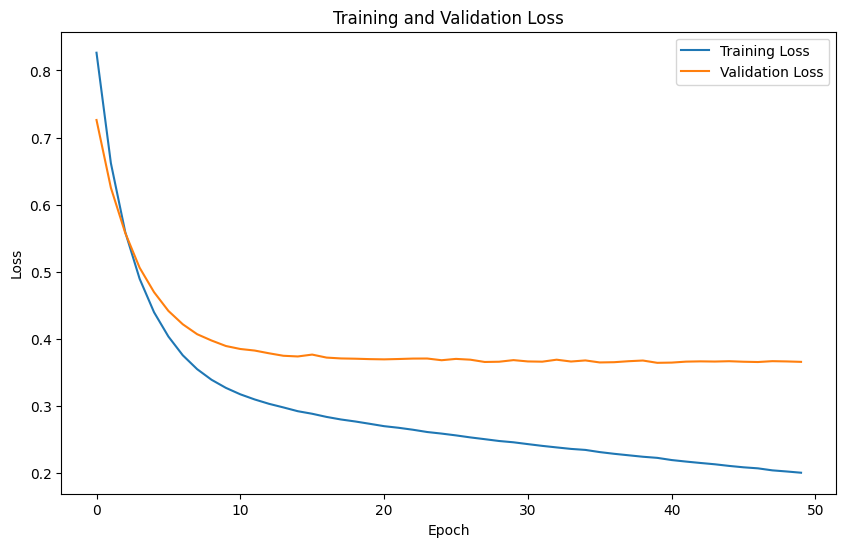

In [4]:
# Graficar función de costo durante el entrenamiento
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [5]:


# Evaluar modelo
y_pred = (model.predict(X_test) > 0.5).astype("int32")
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Métricas de evaluación
print(classification_report(y_test, y_pred))



7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Accuracy: 0.865
              precision    recall  f1-score   support

           0       0.84      0.87      0.86        93
           1       0.88      0.86      0.87       107

    accuracy                           0.86       200
   macro avg       0.86      0.87      0.86       200
weighted avg       0.87      0.86      0.87       200



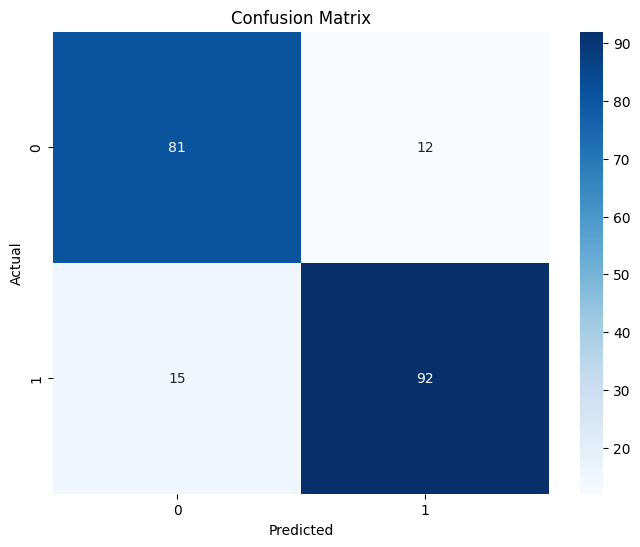

In [6]:
# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [7]:
# Importar librerías
from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import GridSearchCV

# Definir una función para construir el modelo de red neuronal
def create_model(learning_rate=0.01, num_layers=1):
    model = Sequential()
    model.add(Dense(50, input_dim=20, activation='relu'))  # Capa oculta con 50 neuronas y función de activación ReLU
    
    # Añadir capas ocultas adicionales
    for _ in range(num_layers - 1):
        model.add(Dense(50, activation='relu'))
    
    model.add(Dense(1, activation='sigmoid'))  # Capa de salida con una neurona para clasificación binaria y función de activación sigmoide
    
    # Compilar modelo con el learning rate proporcionado
    optimizer = Adam(lr=learning_rate)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Crear modelo KerasClassifier
model = KerasClassifier(build_fn=create_model, epochs=50, batch_size=32, verbose=0)

# Definir los parámetros a buscar
parameters = {
    'learning_rate': [0.001, 0.01, 0.1],
    'num_layers': [1, 2, 3]
}

# Inicializar la búsqueda de hiperparámetros
clf = GridSearchCV(estimator=model, param_grid=parameters, cv=5)

# Realizar la búsqueda de hiperparámetros
clf.fit(X_train, y_train)

# Obtener el mejor modelo
best_model = clf.best_estimator_

# Entrenar el mejor modelo
best_model.fit(X_train, y_train)

# Predecir en conjunto de prueba
y_pred = best_model.predict(X_test)

# Evaluar modelo
accuracy = accuracy_score(y_test, y_pred)
print("Best Model Accuracy:", accuracy)

# Métricas de evaluación
print(classification_report(y_test, y_pred))

# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


ModuleNotFoundError: No module named 'keras.wrappers.scikit_learn'